K=2 클러스터링 임상 분석을 시작합니다...
K=2 클러스터링 확정 및 임상적 특성 분석
임베딩 로드 완료: (5120, 1536)
원본 데이터 로드 완료: (27900, 106)
클러스터 0: 934명 (18.2%)
클러스터 1: 4186명 (81.8%)

클러스터별 주요 임상 지표 분석
분석 대상: 클러스터 0 (934명), 클러스터 1 (4186명)

CC_vas:
  클러스터 0: 4.06 ± 1.97
  클러스터 1: 3.43 ± 2.14
  차이: 0.63
  p-value: 0.0000
  Cohen's d: 0.301
  → 통계적으로 유의한 차이 *** (Small effect)

CMO_before:
  클러스터 0: 37.45 ± 9.79
  클러스터 1: 44.17 ± 7.88
  차이: 6.73
  p-value: 0.0000
  Cohen's d: -0.815
  → 통계적으로 유의한 차이 *** (Large effect)

MMO_before:
  클러스터 0: 43.62 ± 8.07
  클러스터 1: 46.35 ± 6.36
  차이: 2.72
  p-value: 0.0000
  Cohen's d: -0.406
  → 통계적으로 유의한 차이 *** (Small effect)

dif_MMO_CMO:
  클러스터 0: 6.18 ± 6.93
  클러스터 1: 2.18 ± 4.15
  차이: 4.00
  p-value: 0.0000
  Cohen's d: 0.838
  → 통계적으로 유의한 차이 *** (Large effect)

치료 반응성 분석 (첫 방문 vs 마지막 방문)

CC_vas 개선율:
  클러스터 0: 0.0% (n=925)
  클러스터 1: 8.1% (n=4095)
  p-value: 0.0002
  → 클러스터 1가 유의하게 더 큰 개선

CMO_before 개선율:
  클러스터 0: 0.0% (n=934)
  클러스터 1: 30.7% (n=4185)
  p-value: 0.0000
  → 클러스터 1가 유의하게 더 

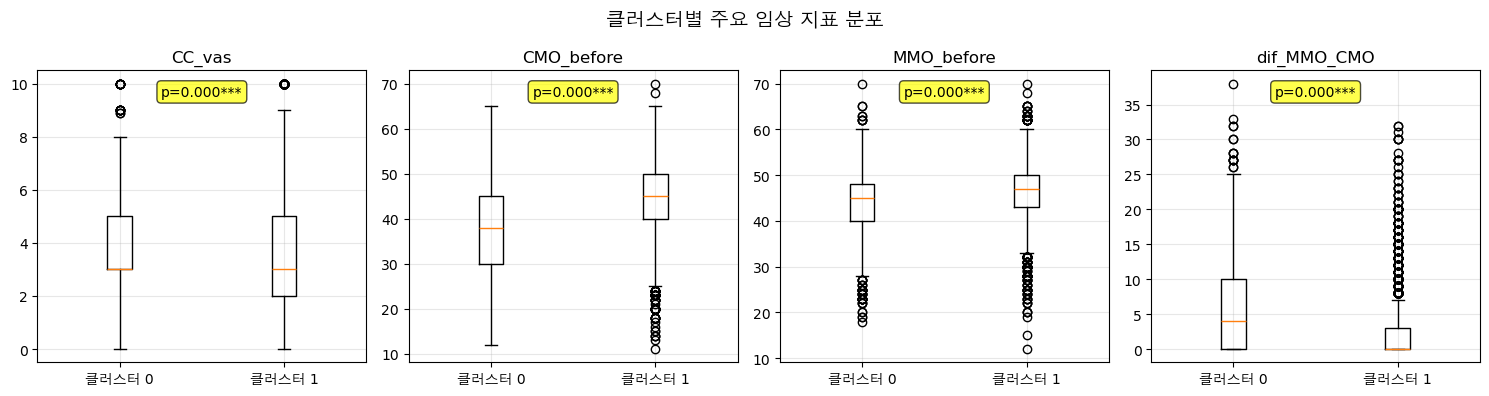

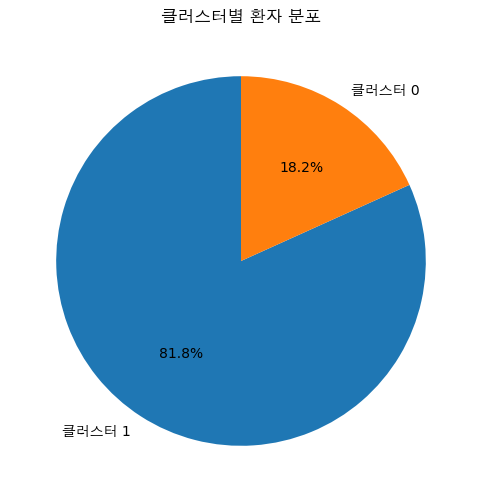


분석이 완료되었습니다!
클러스터 할당 결과가 'cluster' 컬럼에 저장되었습니다.


In [4]:
# -*- coding: utf-8 -*-
import matplotlib
matplotlib.rcParams['font.family'] = ['DejaVu Sans', 'Malgun Gothic', 'AppleGothic', 'Noto Sans CJK KR']
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = ['DejaVu Sans', 'Malgun Gothic', 'AppleGothic', 'Noto Sans CJK KR']
plt.rcParams['axes.unicode_minus'] = False

import matplotlib.pyplot as plt
matplotlib.pyplot.set_loglevel('WARNING')
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 1. 데이터 로드 및 K=2 클러스터링 수행
def run_k2_clustering_analysis():
    """K=2 클러스터링 수행 및 임상 분석"""
    
    print("=" * 60)
    print("K=2 클러스터링 확정 및 임상적 특성 분석")
    print("=" * 60)
    
    # 기존 임베딩 데이터 로드
    import os
    import glob
    import json
    
    embedding_dir = '/Users/nam-yeong/git/prj_centum/gpt_word/final_result/embeddings'
    embedding_files = glob.glob(os.path.join(embedding_dir, '*.json'))
    
    if not embedding_files:
        print("임베딩 파일을 찾을 수 없습니다.")
        return None
    
    # 임베딩 로드
    all_embeddings = []
    patient_ids = []
    
    for file_path in embedding_files:
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
            
            if isinstance(data, list):
                for item in data:
                    if 'embedding' in item and 'patient_id' in item:
                        embedding = np.array(item['embedding']) if isinstance(item['embedding'], list) else item['embedding']
                        all_embeddings.append(embedding)
                        patient_ids.append(item['patient_id'])
        except Exception as e:
            print(f"파일 로드 오류: {e}")
    
    if not all_embeddings:
        print("유효한 임베딩 데이터가 없습니다.")
        return None
    
    embeddings_matrix = np.array(all_embeddings)
    print(f"임베딩 로드 완료: {embeddings_matrix.shape}")
    
    # 원본 데이터 로드
    try:
        df = pd.read_hdf('/Users/nam-yeong/git/prj_centum/gpt_word/final_result/preprocessed_final_df.h5', key='df')
        print(f"원본 데이터 로드 완료: {df.shape}")
    except Exception as e:
        print(f"원본 데이터 로드 오류: {e}")
        return None
    
    # K=2 클러스터링 수행
    scaler = StandardScaler()
    embeddings_scaled = scaler.fit_transform(embeddings_matrix)
    
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings_scaled)
    
    print(f"클러스터 0: {sum(cluster_labels == 0)}명 ({sum(cluster_labels == 0)/len(cluster_labels)*100:.1f}%)")
    print(f"클러스터 1: {sum(cluster_labels == 1)}명 ({sum(cluster_labels == 1)/len(cluster_labels)*100:.1f}%)")
    
    # 환자-클러스터 매핑
    cluster_assignment = pd.DataFrame({
        '환자번호': patient_ids,
        'cluster': cluster_labels
    })
    
    # 원본 데이터에 클러스터 정보 병합
    df_with_clusters = df.merge(cluster_assignment, on='환자번호', how='left')
    
    # 임상적 특성 분석 수행
    analyze_clinical_characteristics_simple(df_with_clusters)
    
    # 시각화
    visualize_cluster_differences_simple(df_with_clusters)
    
    return df_with_clusters, cluster_assignment

def analyze_clinical_characteristics_simple(df_with_clusters):
    """간단한 임상적 특성 분석"""
    
    print("\n" + "=" * 50)
    print("클러스터별 주요 임상 지표 분석")
    print("=" * 50)
    
    # 환자별 마지막 방문 데이터
    patient_last_visits = df_with_clusters.groupby('환자번호').last().reset_index()
    patient_first_visits = df_with_clusters.groupby('환자번호').first().reset_index()
    
    # 클러스터별 분리
    cluster_0 = patient_last_visits[patient_last_visits['cluster'] == 0]
    cluster_1 = patient_last_visits[patient_last_visits['cluster'] == 1]
    
    cluster_0_first = patient_first_visits[patient_first_visits['cluster'] == 0]
    cluster_1_first = patient_first_visits[patient_first_visits['cluster'] == 1]
    
    print(f"분석 대상: 클러스터 0 ({len(cluster_0)}명), 클러스터 1 ({len(cluster_1)}명)")
    
    # 주요 임상 지표 분석
    clinical_metrics = ['CC_vas', 'CMO_before', 'MMO_before', 'dif_MMO_CMO']
    
    significant_differences = []
    
    for metric in clinical_metrics:
        if metric in cluster_0.columns and metric in cluster_1.columns:
            values_0 = cluster_0[metric].dropna()
            values_1 = cluster_1[metric].dropna()
            
            if len(values_0) >= 5 and len(values_1) >= 5:
                mean_0 = values_0.mean()
                std_0 = values_0.std()
                mean_1 = values_1.mean()
                std_1 = values_1.std()
                
                # t-검정
                t_stat, p_value = stats.ttest_ind(values_0, values_1)
                
                # 효과 크기 계산
                pooled_std = np.sqrt(((len(values_0)-1)*std_0**2 + (len(values_1)-1)*std_1**2) / 
                                   (len(values_0) + len(values_1) - 2))
                cohens_d = (mean_0 - mean_1) / pooled_std if pooled_std != 0 else 0
                
                print(f"\n{metric}:")
                print(f"  클러스터 0: {mean_0:.2f} ± {std_0:.2f}")
                print(f"  클러스터 1: {mean_1:.2f} ± {std_1:.2f}")
                print(f"  차이: {abs(mean_0 - mean_1):.2f}")
                print(f"  p-value: {p_value:.4f}")
                print(f"  Cohen's d: {cohens_d:.3f}")
                
                if p_value < 0.05:
                    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*"
                    effect_size = "Large" if abs(cohens_d) >= 0.8 else "Medium" if abs(cohens_d) >= 0.5 else "Small"
                    print(f"  → 통계적으로 유의한 차이 {significance} ({effect_size} effect)")
                    
                    significant_differences.append({
                        'metric': metric,
                        'cluster_0_mean': mean_0,
                        'cluster_1_mean': mean_1,
                        'p_value': p_value,
                        'cohens_d': cohens_d
                    })
    
    # 치료 반응성 분석
    print(f"\n" + "=" * 50)
    print("치료 반응성 분석 (첫 방문 vs 마지막 방문)")
    print("=" * 50)
    
    for metric in ['CC_vas', 'CMO_before', 'MMO_before']:
        if (metric in cluster_0_first.columns and metric in cluster_0.columns and
            metric in cluster_1_first.columns and metric in cluster_1.columns):
            
            # 변화율 계산
            def calculate_improvement(first_df, last_df, metric_name):
                improvements = []
                for _, patient in first_df.iterrows():
                    patient_id = patient['환자번호']
                    first_val = patient[metric_name]
                    
                    last_patient = last_df[last_df['환자번호'] == patient_id]
                    if not last_patient.empty:
                        last_val = last_patient[metric_name].iloc[0]
                        
                        if pd.notna(first_val) and pd.notna(last_val) and first_val != 0:
                            if metric_name == 'CC_vas':
                                # VAS는 감소가 개선
                                improvement = (first_val - last_val) / first_val * 100
                            else:
                                # 개구량은 증가가 개선
                                improvement = (last_val - first_val) / first_val * 100
                            improvements.append(improvement)
                return improvements
            
            improvements_0 = calculate_improvement(cluster_0_first, cluster_0, metric)
            improvements_1 = calculate_improvement(cluster_1_first, cluster_1, metric)
            
            if len(improvements_0) >= 3 and len(improvements_1) >= 3:
                mean_imp_0 = np.mean(improvements_0)
                mean_imp_1 = np.mean(improvements_1)
                
                t_stat, p_value = stats.ttest_ind(improvements_0, improvements_1)
                
                print(f"\n{metric} 개선율:")
                print(f"  클러스터 0: {mean_imp_0:.1f}% (n={len(improvements_0)})")
                print(f"  클러스터 1: {mean_imp_1:.1f}% (n={len(improvements_1)})")
                print(f"  p-value: {p_value:.4f}")
                
                if p_value < 0.05:
                    better_cluster = 0 if mean_imp_0 > mean_imp_1 else 1
                    print(f"  → 클러스터 {better_cluster}가 유의하게 더 큰 개선")
    
    # 요약 및 임상적 해석
    print(f"\n" + "=" * 50)
    print("임상적 해석")
    print("=" * 50)
    
    if significant_differences:
        # VAS 기준으로 클러스터 특성화
        vas_diff = None
        mmo_diff = None
        
        for diff in significant_differences:
            if diff['metric'] == 'CC_vas':
                vas_diff = diff
            elif diff['metric'] == 'MMO_before':
                mmo_diff = diff
        
        if vas_diff:
            low_pain_cluster = 0 if vas_diff['cluster_0_mean'] < vas_diff['cluster_1_mean'] else 1
            high_pain_cluster = 1 - low_pain_cluster
            
            print(f"통증 수준 기준:")
            print(f"  클러스터 {low_pain_cluster}: 저통증군 (VAS {vas_diff[f'cluster_{low_pain_cluster}_mean']:.1f})")
            print(f"  클러스터 {high_pain_cluster}: 고통증군 (VAS {vas_diff[f'cluster_{high_pain_cluster}_mean']:.1f})")
        
        if mmo_diff:
            good_opening_cluster = 0 if mmo_diff['cluster_0_mean'] > mmo_diff['cluster_1_mean'] else 1
            poor_opening_cluster = 1 - good_opening_cluster
            
            print(f"\n개구 기능 기준:")
            print(f"  클러스터 {good_opening_cluster}: 양호한 개구군 (MMO {mmo_diff[f'cluster_{good_opening_cluster}_mean']:.1f}mm)")
            print(f"  클러스터 {poor_opening_cluster}: 제한된 개구군 (MMO {mmo_diff[f'cluster_{poor_opening_cluster}_mean']:.1f}mm)")
        
        print(f"\n임상적 의의:")
        print("1. TMD 환자는 2개의 뚜렷한 임상적 아형으로 구분됨")
        print("2. 각 아형은 서로 다른 증상 중증도와 기능적 제한을 보임") 
        print("3. 개인맞춤형 치료 전략 수립의 근거가 될 수 있음")
    else:
        print("주요 임상 지표에서 클러스터 간 유의한 차이를 발견하지 못했습니다.")
        print("추가적인 특성 분석이 필요할 수 있습니다.")

def visualize_cluster_differences_simple(df_with_clusters):
    """간단한 클러스터 차이 시각화"""
    
    # 환자별 마지막 방문 데이터
    patient_last_visits = df_with_clusters.groupby('환자번호').last().reset_index()
    
    # 주요 임상 지표들
    metrics = ['CC_vas', 'CMO_before', 'MMO_before', 'dif_MMO_CMO']
    available_metrics = [m for m in metrics if m in patient_last_visits.columns]
    
    if available_metrics:
        n_metrics = len(available_metrics)
        fig, axes = plt.subplots(1, min(n_metrics, 4), figsize=(15, 4))
        if n_metrics == 1:
            axes = [axes]
        
        for i, metric in enumerate(available_metrics[:4]):
            cluster_0_data = patient_last_visits[patient_last_visits['cluster'] == 0][metric].dropna()
            cluster_1_data = patient_last_visits[patient_last_visits['cluster'] == 1][metric].dropna()
            
            if len(cluster_0_data) > 0 and len(cluster_1_data) > 0:
                # 박스플롯
                data = [cluster_0_data, cluster_1_data]
                labels = ['클러스터 0', '클러스터 1']
                
                axes[i].boxplot(data, labels=labels)
                axes[i].set_title(f'{metric}')
                axes[i].grid(True, alpha=0.3)
                
                # 통계적 검정 결과 표시
                t_stat, p_value = stats.ttest_ind(cluster_0_data, cluster_1_data)
                if p_value < 0.05:
                    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*"
                    axes[i].text(0.5, 0.95, f'p={p_value:.3f}{significance}', 
                               transform=axes[i].transAxes, ha='center', va='top',
                               bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
        
        plt.suptitle('클러스터별 주요 임상 지표 분포', fontsize=14)
        plt.tight_layout()
        plt.show()
    
    # 클러스터 크기 파이차트
    cluster_counts = patient_last_visits['cluster'].value_counts()
    
    plt.figure(figsize=(8, 6))
    plt.pie(cluster_counts.values, labels=[f'클러스터 {i}' for i in cluster_counts.index], 
            autopct='%1.1f%%', startangle=90)
    plt.title('클러스터별 환자 분포')
    plt.show()

# 실행
if __name__ == "__main__":
    print("K=2 클러스터링 임상 분석을 시작합니다...")
    try:
        df_with_clusters, cluster_assignment = run_k2_clustering_analysis()
        
        if df_with_clusters is not None:
            print(f"\n분석이 완료되었습니다!")
            print(f"클러스터 할당 결과가 'cluster' 컬럼에 저장되었습니다.")
        else:
            print("분석 중 오류가 발생했습니다.")
    except Exception as e:
        print(f"실행 중 오류: {e}")
        import traceback
        traceback.print_exc()